# 02 — Exploratory Data Analysis

Sanity-checks the preprocessed dataset before any model training.
Verifies class distributions, volume integrity, visual appearance, and intensity consistency.

**Run after:** `01_preprocessing.ipynb`  
**Run before:** `03_train_binary.ipynb`

At the end, Cell 9 prints an explicit go/no-go checklist.
Do not proceed to 03 unless all checks pass.

In [1]:
# ── Cell 1: Install dependencies ──────────────────────────────────────────────
!pip install nibabel matplotlib seaborn -q

In [2]:
# ── Cell 2: Imports & Drive mount ─────────────────────────────────────────────
import os, random, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted.')

Mounted at /content/drive
Drive mounted.


In [3]:
# ── Cell 3: Config ────────────────────────────────────────────────────────────
MANIFEST_CSV = '/content/drive/MyDrive/GlioGradev2/preprocessed/manifest.csv'

# Short display names for the 4 WHO 2021 type labels
TYPE_SHORT = {
    'Glioblastoma, IDH-wildtype':                       'GBM',
    'Astrocytoma, IDH-wildtype':                        'Astro WT',
    'Oligodendroglioma, IDH-mutant, 1p/19q-codeleted': 'Oligo',
    'Astrocytoma, IDH-mutant':                          'Astro MT',
}
TYPE_COLORS  = ['#e74c3c', '#e67e22', '#3498db', '#2ecc71']
GRADE_COLORS = ['#2ecc71', '#e67e22', '#e74c3c']

print(f'Manifest: {MANIFEST_CSV}')

Manifest: /content/drive/MyDrive/GlioGradev2/preprocessed/manifest.csv


In [4]:
# ── Cell 4: Load manifest & basic stats ───────────────────────────────────────
if not Path(MANIFEST_CSV).exists():
    raise FileNotFoundError(f'manifest.csv not found. Run 01_preprocessing.ipynb first.\n{MANIFEST_CSV}')

df = pd.read_csv(MANIFEST_CSV)
print(f'Manifest shape : {df.shape}')
print(f'Columns        : {list(df.columns)}')
print()

# Null check
nulls = df.isnull().sum()
if nulls.any():
    print('⚠️  Null values found:')
    print(nulls[nulls > 0])
else:
    print('✅  No null values in manifest.')

# Per-split counts
print()
print('── Patient counts per split ────────────────')
for split in ['train', 'val', 'test']:
    n = (df['split'] == split).sum()
    print(f'  {split:<6}: {n:>4}  ({100*n/len(df):.1f}%)')
print(f'  {"total":<6}: {len(df):>4}')

# Add short type name for plots
df['type_short'] = df['type_label'].map(TYPE_SHORT)
print()
df.head(3)

Manifest shape : (495, 7)
Columns        : ['patient_id', 'npy_path', 'split', 'type_label', 'type_idx', 'grade_label', 'grade_idx']

✅  No null values in manifest.

── Patient counts per split ────────────────
  train :  346  (69.9%)
  val   :   74  (14.9%)
  test  :   75  (15.2%)
  total :  495



,patient_id,npy_path,split,type_label,type_idx,grade_label,grade_idx,type_short
0,323,/content/drive/MyDrive/GlioGradev2/preprocesse...,train,"Glioblastoma, IDH-wildtype",0,4,2,GBM
1,300,/content/drive/MyDrive/GlioGradev2/preprocesse...,train,"Astrocytoma, IDH-mutant",3,2,0,Astro MT
2,115,/content/drive/MyDrive/GlioGradev2/preprocesse...,train,"Glioblastoma, IDH-wildtype",0,4,2,GBM


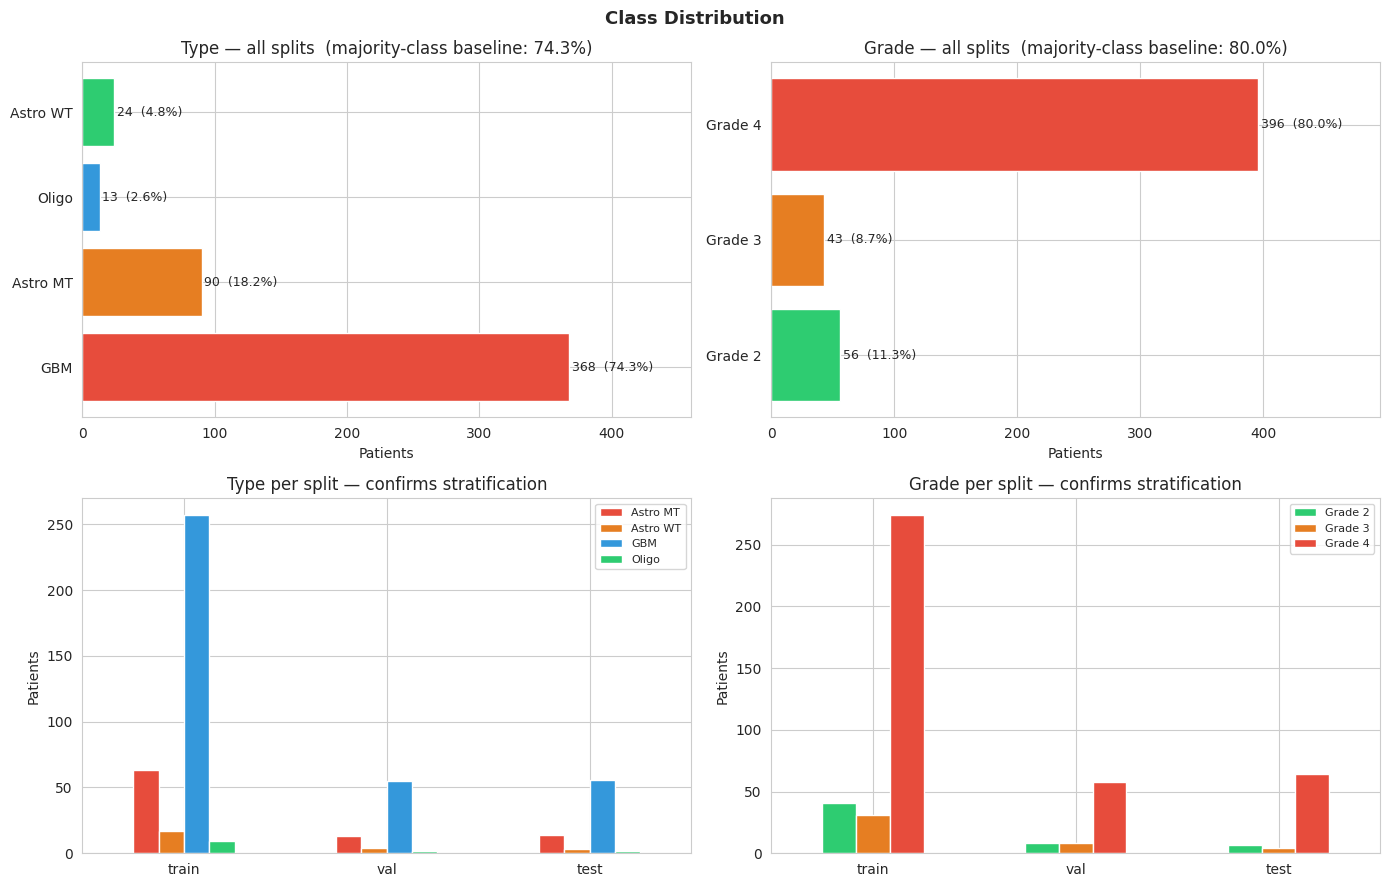

⚠️  Remember: plain accuracy is misleading on this data.
   Type majority baseline  : 74.3%
   Grade majority baseline : 80.0%
   Use balanced accuracy / macro F1 / Kappa as primary metrics.


In [5]:
# ── Cell 5: Class distributions ───────────────────────────────────────────────
# Shows type + grade distribution overall and broken down per split.
# The per-split breakdown confirms stratification preserved class proportions.

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Class Distribution', fontsize=13, fontweight='bold')

# ── Overall type
ax = axes[0, 0]
type_counts = df['type_short'].value_counts().reindex(['GBM', 'Astro MT', 'Oligo', 'Astro WT'])
bars = ax.barh(type_counts.index, type_counts.values, color=TYPE_COLORS)
for bar, n in zip(bars, type_counts.values):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            f'{n}  ({100*n/len(df):.1f}%)', va='center', fontsize=9)
baseline = type_counts.max() / len(df)
ax.set_title(f'Type — all splits  (majority-class baseline: {baseline:.1%})')
ax.set_xlabel('Patients')
ax.set_xlim(0, type_counts.max() * 1.25)

# ── Overall grade
ax = axes[0, 1]
grade_counts = df.groupby('grade_label').size().sort_index()
bars = ax.barh([f'Grade {g}' for g in grade_counts.index], grade_counts.values, color=GRADE_COLORS)
for bar, n in zip(bars, grade_counts.values):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            f'{n}  ({100*n/len(df):.1f}%)', va='center', fontsize=9)
baseline = grade_counts.max() / len(df)
ax.set_title(f'Grade — all splits  (majority-class baseline: {baseline:.1%})')
ax.set_xlabel('Patients')
ax.set_xlim(0, grade_counts.max() * 1.25)

# ── Type per split (grouped bar)
ax = axes[1, 0]
type_split = df.groupby(['split', 'type_short']).size().unstack(fill_value=0)
type_split = type_split.reindex(['train', 'val', 'test'])
type_split.plot(kind='bar', ax=ax, color=TYPE_COLORS, rot=0, legend=True)
ax.set_title('Type per split — confirms stratification')
ax.set_xlabel('')
ax.set_ylabel('Patients')
ax.legend(fontsize=8, loc='upper right')

# ── Grade per split (grouped bar)
ax = axes[1, 1]
grade_split = df.groupby(['split', 'grade_label']).size().unstack(fill_value=0)
grade_split = grade_split.reindex(['train', 'val', 'test'])
grade_split.columns = [f'Grade {g}' for g in grade_split.columns]
grade_split.plot(kind='bar', ax=ax, color=GRADE_COLORS, rot=0, legend=True)
ax.set_title('Grade per split — confirms stratification')
ax.set_xlabel('')
ax.set_ylabel('Patients')
ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()

print('⚠️  Remember: plain accuracy is misleading on this data.')
print(f'   Type majority baseline  : {df["type_label"].value_counts().iloc[0]/len(df):.1%}')
print(f'   Grade majority baseline : {df["grade_label"].value_counts().iloc[0]/len(df):.1%}')
print('   Use balanced accuracy / macro F1 / Kappa as primary metrics.')

In [6]:
# ── Cell 6: Volume integrity check ────────────────────────────────────────────
# Checks every .npy file: exists, correct shape, correct dtype.
# Uses mmap_mode='r' for shape/dtype — does NOT load full arrays into RAM.
# Does a full load on 10 random files to verify value range [0, 1].

TARGET_SHAPE = (96, 96, 96)

missing      = []
wrong_shape  = []
wrong_dtype  = []

print(f'Checking {len(df)} files (shape/dtype only — no full load)...')
for _, row in df.iterrows():
    p = Path(row['npy_path'])
    if not p.exists():
        missing.append(row['patient_id'])
        continue
    vol = np.load(str(p), mmap_mode='r')
    if vol.shape != TARGET_SHAPE:
        wrong_shape.append((row['patient_id'], vol.shape))
    if vol.dtype != np.float32:
        wrong_dtype.append((row['patient_id'], vol.dtype))

print(f'  Missing files    : {len(missing)}')
print(f'  Wrong shape      : {len(wrong_shape)}')
print(f'  Wrong dtype      : {len(wrong_dtype)}')

if missing:     print(f'  ❌  Missing: {missing[:5]}')
if wrong_shape: print(f'  ❌  Wrong shape examples: {wrong_shape[:3]}')
if wrong_dtype: print(f'  ❌  Wrong dtype examples: {wrong_dtype[:3]}')

# Full load on 10 random files — check value range
print()
print('Full range check on 10 random files:')
sample_rows = df.sample(min(10, len(df)), random_state=SEED)
range_errors = []
for _, row in sample_rows.iterrows():
    vol = np.load(str(row['npy_path']))
    vmin, vmax = float(vol.min()), float(vol.max())
    ok = (vmin >= 0.0 and vmax <= 1.0)
    icon = '✅' if ok else '❌'
    print(f'  {icon}  {row["patient_id"]}  [{vmin:.4f}, {vmax:.4f}]  zeros={( vol==0).mean():.1%}')
    if not ok:
        range_errors.append(row['patient_id'])

print()
if not any([missing, wrong_shape, wrong_dtype, range_errors]):
    print('✅  All integrity checks passed.')
else:
    print('❌  Issues found — do not proceed to training until resolved.')

Checking 495 files (shape/dtype only — no full load)...
  Missing files    : 0
  Wrong shape      : 0
  Wrong dtype      : 0

Full range check on 10 random files:
  ✅  385  [0.1495, 1.0000]  zeros=0.0%
  ✅  46  [0.2222, 1.0000]  zeros=0.0%
  ✅  144  [0.1390, 1.0000]  zeros=0.0%
  ✅  200  [0.1655, 1.0000]  zeros=0.0%
  ✅  308  [0.0306, 1.0000]  zeros=0.0%
  ✅  502  [0.1586, 1.0000]  zeros=0.0%
  ✅  359  [0.2091, 1.0000]  zeros=0.0%
  ✅  327  [0.1803, 1.0000]  zeros=0.0%
  ✅  25  [0.1830, 1.0000]  zeros=0.0%
  ✅  43  [0.1806, 1.0000]  zeros=0.0%

✅  All integrity checks passed.


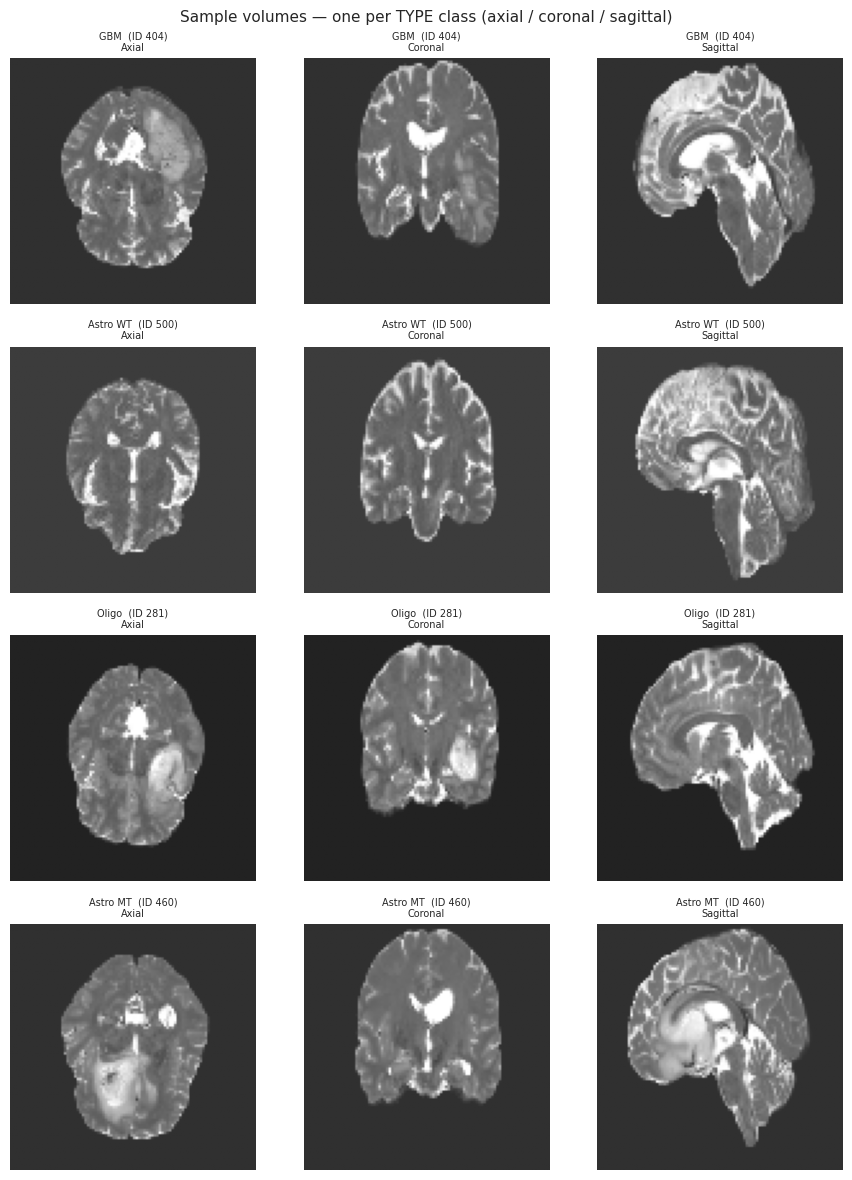

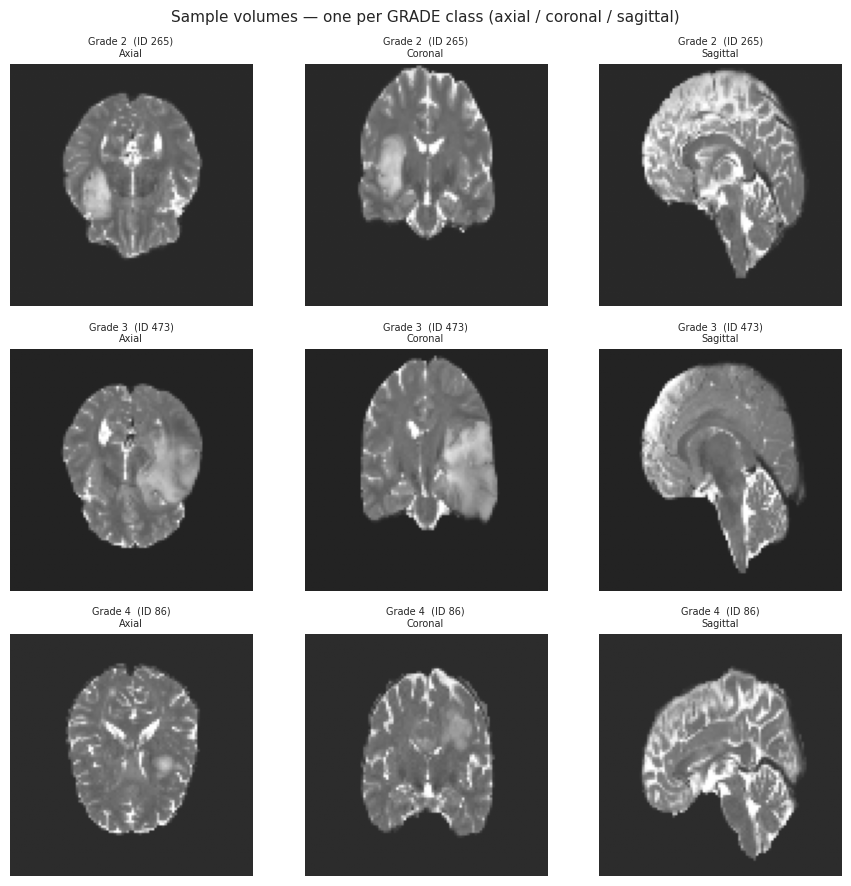

In [7]:
# ── Cell 7: Sample slices per class ───────────────────────────────────────────
# Visual QC — one representative patient per type class and per grade class.
# Shows axial, coronal, sagittal middle slices for each.

def get_representative(df, col, val):
    """Return path of one patient from the training split for a given class."""
    subset = df[(df[col] == val) & (df['split'] == 'train')]
    if len(subset) == 0:
        subset = df[df[col] == val]
    return subset.sample(1, random_state=SEED).iloc[0]

def show_three_planes(ax_row, npy_path, title):
    vol = np.load(str(npy_path))
    cx, cy, cz = [s // 2 for s in vol.shape]
    planes = [
        ('Axial',     np.rot90(vol[:, :, cz])),
        ('Coronal',   np.rot90(vol[:, cy, :])),
        ('Sagittal',  np.rot90(vol[cx, :, :])),
    ]
    for ax, (plane_name, img) in zip(ax_row, planes):
        ax.imshow(img, cmap='gray', vmin=0, vmax=1)
        ax.set_title(f'{title}\n{plane_name}', fontsize=7)
        ax.axis('off')

# ── Type classes (4 rows × 3 planes)
type_order = [
    'Glioblastoma, IDH-wildtype',
    'Astrocytoma, IDH-wildtype',
    'Oligodendroglioma, IDH-mutant, 1p/19q-codeleted',
    'Astrocytoma, IDH-mutant',
]

fig, axes = plt.subplots(4, 3, figsize=(9, 12))
fig.suptitle('Sample volumes — one per TYPE class (axial / coronal / sagittal)', fontsize=11)
for i, label in enumerate(type_order):
    row = get_representative(df, 'type_label', label)
    short = TYPE_SHORT.get(label, label)
    show_three_planes(axes[i], row['npy_path'], f'{short}  (ID {row["patient_id"]})')
plt.tight_layout()
plt.show()

# ── Grade classes (3 rows × 3 planes)
fig, axes = plt.subplots(3, 3, figsize=(9, 9))
fig.suptitle('Sample volumes — one per GRADE class (axial / coronal / sagittal)', fontsize=11)
for i, grade in enumerate([2, 3, 4]):
    row = get_representative(df, 'grade_label', grade)
    show_three_planes(axes[i], row['npy_path'], f'Grade {grade}  (ID {row["patient_id"]})')
plt.tight_layout()
plt.show()

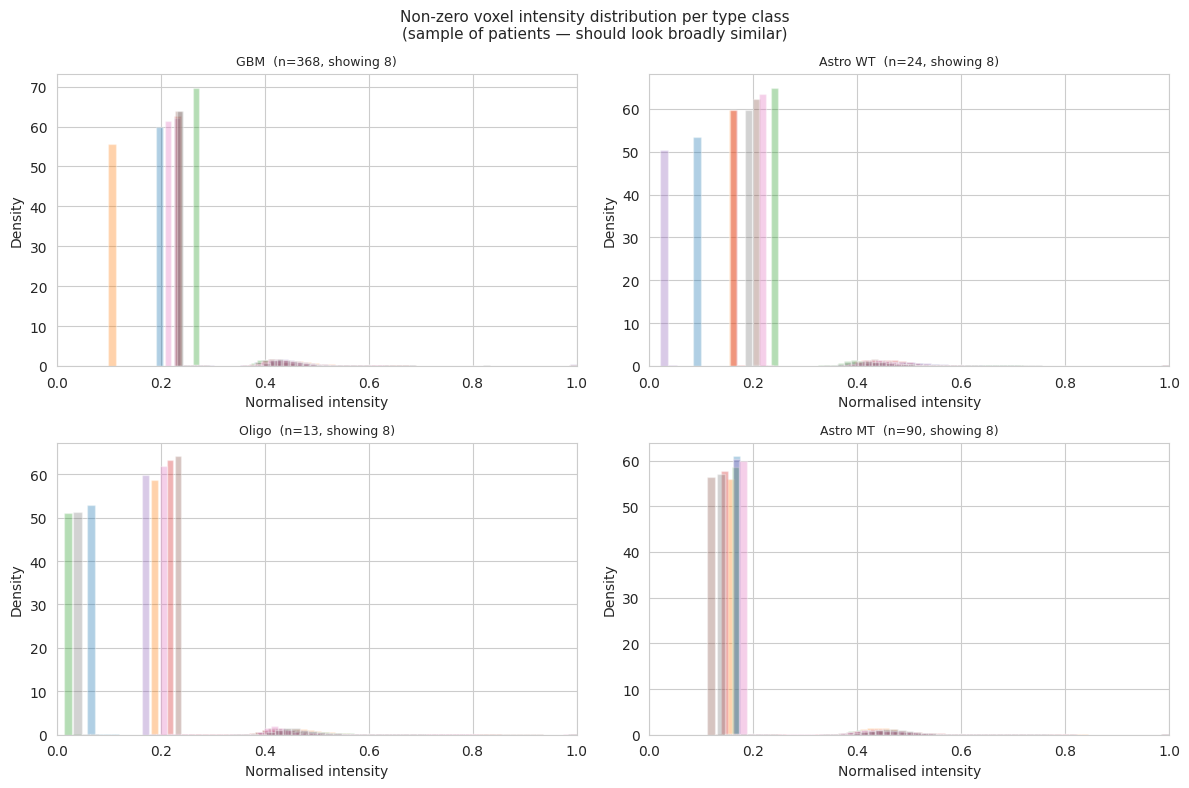

Each line is one patient. Overlapping curves = consistent preprocessing.
Outlier lines = a patient worth investigating manually.


In [8]:
# ── Cell 8: Intensity distribution per type class ─────────────────────────────
# Samples up to 8 patients per class and plots a histogram of non-zero voxel
# intensities. Distributions should look broadly similar (same scanner protocol).
# Large divergences suggest a preprocessing inconsistency.

SAMPLE_PER_CLASS = 8

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Non-zero voxel intensity distribution per type class\n(sample of patients — should look broadly similar)', fontsize=11)

for ax, (label, short) in zip(axes.flat, TYPE_SHORT.items()):
    subset = df[df['type_label'] == label].sample(
        min(SAMPLE_PER_CLASS, (df['type_label'] == label).sum()),
        random_state=SEED
    )
    for _, row in subset.iterrows():
        vol = np.load(str(row['npy_path']))
        nonzero = vol[vol > 0].flatten()
        ax.hist(nonzero, bins=60, alpha=0.35, density=True)

    n_class = (df['type_label'] == label).sum()
    ax.set_title(f'{short}  (n={n_class}, showing {len(subset)})', fontsize=9)
    ax.set_xlabel('Normalised intensity')
    ax.set_ylabel('Density')
    ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()
print('Each line is one patient. Overlapping curves = consistent preprocessing.')
print('Outlier lines = a patient worth investigating manually.')

In [9]:
# ── Cell 9: Go / no-go checklist ──────────────────────────────────────────────
# Re-runs all checks programmatically and prints a final verdict.

SEP = '═' * 58
checks = []

def check(label, condition, detail=''):
    icon = '✅' if condition else '❌'
    suffix = f'  ({detail})' if detail else ''
    print(f'  {icon}  {label}{suffix}')
    checks.append(condition)

print(SEP)
print('  GO / NO-GO CHECKLIST')
print(SEP)

# 1. Manifest loaded OK
check('Manifest CSV loaded', len(df) > 0, f'{len(df)} rows')

# 2. No nulls
check('No null values in manifest', df.isnull().sum().sum() == 0)

# 3. All 3 splits present
check('All 3 splits present (train/val/test)', set(df['split']) == {'train', 'val', 'test'})

# 4. Reasonable patient count
check('At least 400 usable patients', len(df) >= 400, f'{len(df)} patients')

# 5. All 4 type classes present in training split
train_types = set(df[df['split']=='train']['type_idx'])
check('All 4 type classes in training split', train_types == {0,1,2,3}, str(train_types))

# 6. All 3 grade classes present in training split
train_grades = set(df[df['split']=='train']['grade_idx'])
check('All 3 grade classes in training split', train_grades == {0,1,2}, str(train_grades))

# 7. No missing .npy files
check('No missing .npy files', len(missing) == 0,
      f'{len(missing)} missing' if missing else 'all present')

# 8. No shape errors
check(f'All volumes shape {TARGET_SHAPE}', len(wrong_shape) == 0,
      f'{len(wrong_shape)} wrong' if wrong_shape else 'all correct')

# 9. No dtype errors
check('All volumes dtype float32', len(wrong_dtype) == 0,
      f'{len(wrong_dtype)} wrong' if wrong_dtype else 'all correct')

# 10. No range errors in sampled files
check('Value range [0, 1] in sampled files', len(range_errors) == 0,
      f'{len(range_errors)} out-of-range' if range_errors else 'all pass')

print()
all_pass = all(checks)
print(SEP)
if all_pass:
    print('  ✅  ALL CHECKS PASSED — proceed to 03_train_binary.ipynb')
else:
    n_fail = sum(1 for c in checks if not c)
    print(f'  ❌  {n_fail} CHECK(S) FAILED — resolve before training')
print(SEP)

══════════════════════════════════════════════════════════
  GO / NO-GO CHECKLIST
══════════════════════════════════════════════════════════
  ✅  Manifest CSV loaded  (495 rows)
  ✅  No null values in manifest
  ✅  All 3 splits present (train/val/test)
  ✅  At least 400 usable patients  (495 patients)
  ✅  All 4 type classes in training split  ({0, 1, 2, 3})
  ✅  All 3 grade classes in training split  ({0, 1, 2})
  ✅  No missing .npy files  (all present)
  ✅  All volumes shape (96, 96, 96)  (all correct)
  ✅  All volumes dtype float32  (all correct)
  ✅  Value range [0, 1] in sampled files  (all pass)

══════════════════════════════════════════════════════════
  ✅  ALL CHECKS PASSED — proceed to 03_train_binary.ipynb
══════════════════════════════════════════════════════════
